In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
# 1. Load Dataset
# ------------------------------

data = load_breast_cancer()
X = data.data
y = data.target

In [7]:
# 2. Train-Test Split
# ------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
# 3. Feature Scaling
# ------------------------------

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
# 4. Define Models
# ------------------------------

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

In [10]:
# 5. Train & Evaluate
# ------------------------------

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

In [11]:
# 6. Create Comparison Table
# ------------------------------

comparison_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

print("\nModel Comparison Table:\n")
print(comparison_df)


Model Comparison Table:

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.982456   0.986111  0.986111  0.986111
1        Decision Tree  0.912281   0.955882  0.902778  0.928571
2        Random Forest  0.956140   0.958904  0.972222  0.965517
3                  SVM  0.982456   0.986111  0.986111  0.986111


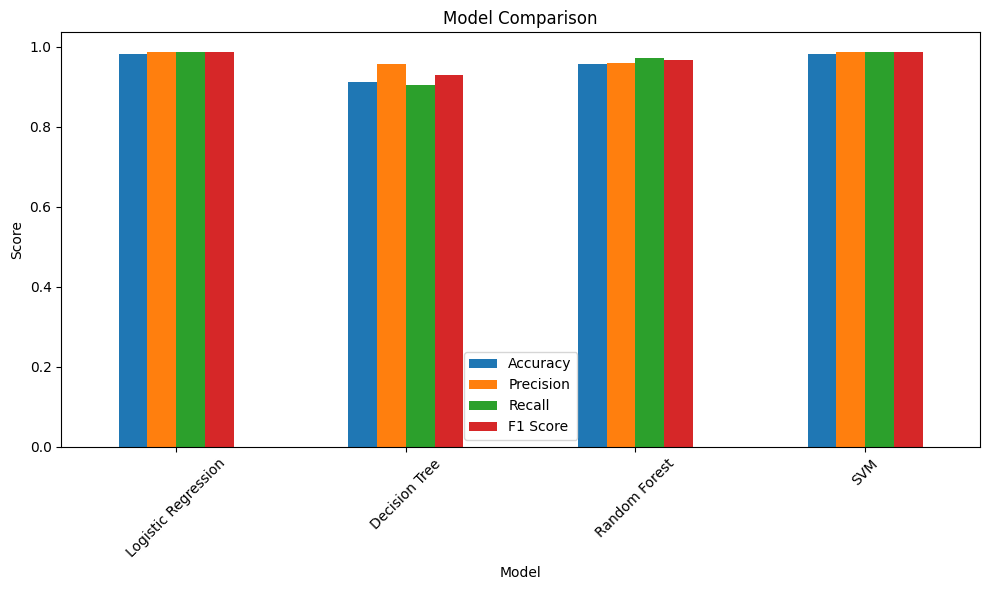

In [12]:
# 7. Plot Comparison
# ------------------------------

comparison_df.set_index("Model").plot(kind="bar", figsize=(10,6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# 8. Select Best Model
# ------------------------------

best_model_name = comparison_df.sort_values("F1 Score", ascending=False).iloc[0]["Model"]
print("\nBest Model Based on F1 Score:", best_model_name)

best_model = models[best_model_name]


Best Model Based on F1 Score: Logistic Regression


In [14]:
# 9. Save Best Model
# ------------------------------

pickle.dump(best_model, open("best_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("\nBest model saved successfully!")


Best model saved successfully!
